Sources:
    For my same author texts, I am using Agatha Christie's "The murder of Roger Ackroyd" and "The Man in the Brown Suit"
    For my different author texts, I am using "The Return of Sherlock Holmes" by Arthur Conan Doyle and "The House on the Borderland" by William Hope Hodgson.

Goals:
    I want to cycle through each of my selected texts and numerically rank the presence of certain words. These ranked word lists can then be compared to one another to infer differences from author to author, as well as seperate texts from the same author. There might be some pattern that relates to the author or time period that could be conveyed onto similar texts.

How:
    The code will cycle through each spaced word and document the actual words to a dictionary array. At the end of the text, the frequencies of the words are recorded and listed in numerical order. These results can then be visualized or further mathmatically analyzed.


In [6]:
import nltk

nltk.download('stopwords', quiet=True)


True

In [7]:
import requests, re, nltk
from bs4 import BeautifulSoup
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub(r"[,\".\'&|:@>*;/=“”‘’!?(){}\[\]-]", "", w)
    # get rid of numbers
    return re.sub(r'^[0-9.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re.split(r'\s+', t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    wf.pop('', None)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('https://www.gutenberg.org/cache/epub/69087/pg69087.txt')
(wf_bu, tw_bu) = get_wf('https://www.gutenberg.org/cache/epub/61168/pg61168.txt')

print(wf_ee)
print(tw_ee)
print(wf_bu)
print(tw_bu)

[('would', 161), ('little', 165), ('inspector', 166), ('see', 171), ('man', 171), ('miss', 172), ('flora', 173), ('mr', 182), ('ralph', 185), ('caroline', 208), ('know', 216), ('one', 292), ('ackroyd', 339), ('poirot', 439), ('said', 795)]
36362
[('race', 144), ('anne', 144), ('think', 145), ('could', 151), ('time', 154), ('dont', 165), ('like', 165), ('know', 196), ('pagett', 199), ('eustace', 218), ('would', 219), ('sir', 252), ('man', 256), ('one', 339), ('said', 391)]
37634


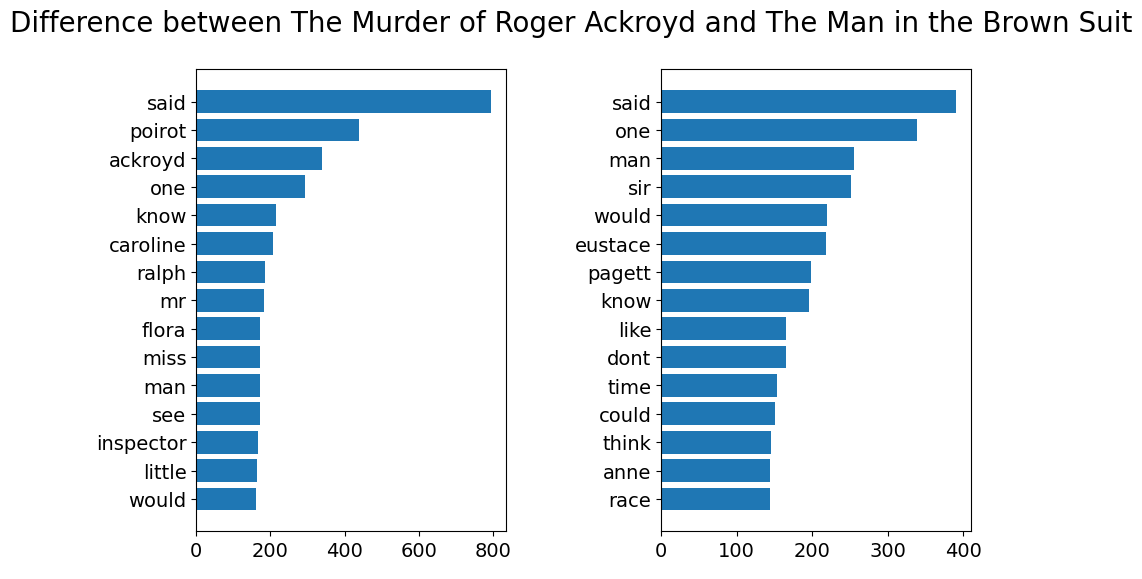

In [8]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top=False, bottom=False, left=False, right=False, labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    ax1.set_yticks(pos)
    ax1.set_yticklabels([x[0] for x in wf_ee])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)) 
    ax2.set_yticks(pos)
    ax2.set_yticklabels([x[0] for x in wf_bu])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between The Murder of Roger Ackroyd and The Man in the Brown Suit')
plt.show()